# Part 1: Multiple choice questions

## Q1


In [7]:
import pandas as pd
order= pd.read_csv('./data/orders.csv', parse_dates=['order_date'])

order = order.sort_values(['customer_id', 'order_date'])
order['gap'] = order.groupby('customer_id')['order_date'].diff().dt.days

# Loại bỏ các giá trị NaN (đơn hàng đầu tiên của mỗi khách) và tính trung vị
median_gap = order['gap'].dropna().median()
print(f"Trung vị số ngày giữa 2 lần mua: {median_gap}")

Trung vị số ngày giữa 2 lần mua: 144.0


# 1. Customer Insights
Phân đoạn khách hàng (RFM Analysis): Dựa trên orders, customers và payments để tính toán:

* Recency: Lần mua gần nhất.
* Frequency: Tần suất mua hàng.
* Monetary: Tổng số tiền đã chi tiêu.
Mục tiêu: Chia khách hàng thành các nhóm (VIP, Khách hàng trung thành, Khách hàng sắp rời bỏ) để đề xuất chiến dịch marketing riêng biệt.

Customer Retention & Churn: Tính tỷ lệ khách hàng quay lại mua hàng. Phân tích "inter-order gap" (như câu hỏi Q1 bạn nêu) để biết sau bao lâu khách hàng thường mua lại, từ đó thiết lập thời điểm gửi email nhắc nhở (Remind email).

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# 1. Đọc dữ liệu (Giả sử các file nằm cùng thư mục)
orders = pd.read_csv('./data/orders.csv', parse_dates=['order_date'])
payments = pd.read_csv('./data/payments.csv') # Cần cột order_id và payment_value

In [ ]:


# 2. Kết hợp bảng để có thông tin doanh thu mỗi đơn hàng
# Giả sử mỗi order_id trong payments có tổng số tiền
order_payment = payments.groupby('order_id')['payment_value'].sum().reset_index()
df = pd.merge(orders, order_payment, on='order_id', how='left')

# 3. Tính toán RFM
# Giả sử ngày hiện tại là ngày sau đơn hàng cuối cùng 1 ngày
snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days, # Recency
    'order_id': 'count',                                   # Frequency
    'payment_value': 'sum'                                 # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# 4. Phân nhóm theo Tứ phân vị (Quartiles)
# Điểm 1 là tốt nhất cho Frequency/Monetary, nhưng Recency thấp (mới mua) mới là tốt
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

# Tính điểm RFM tổng hợp
rfm['RFM_Segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_Score'] = rfm[['R_score', 'F_score', 'M_score']].sum(axis=1)

print(rfm.head())

             Recency  Frequency   Monetary R_score F_score M_score  \
customer_id                                                          
1                617          6  142803.47       3       3       3   
2                179          4  204693.89       4       2       3   
3               3443          3   52093.47       1       2       2   
4                917          1   10939.06       3       1       1   
5               1376          5   64179.86       2       3       2   

            RFM_Segment  RFM_Score  
customer_id                         
1                   333          9  
2                   423          9  
3                   122          5  
4                   311          5  
5                   232          7  


Trung vị số ngày giữa 2 lần mua: 144.0 ngày


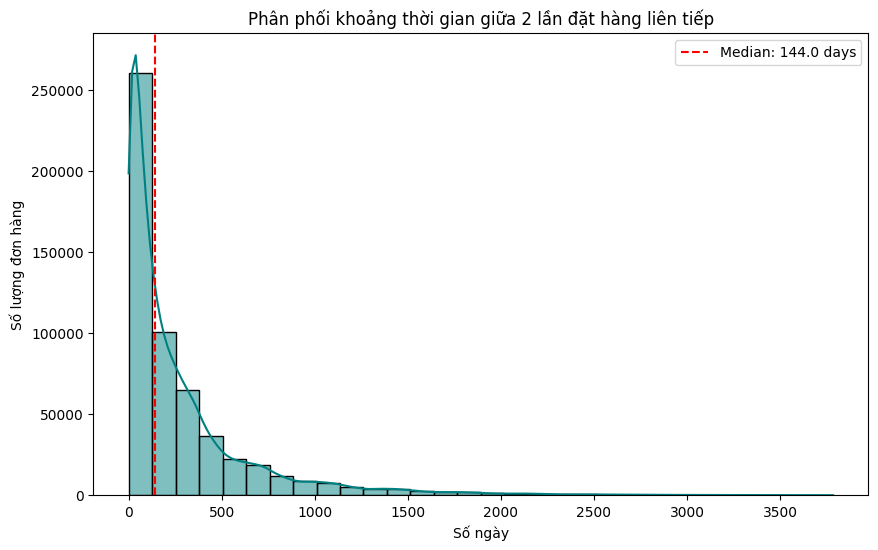

In [14]:
# Sắp xếp theo khách hàng và ngày đặt hàng
df_sorted = df.sort_values(['customer_id', 'order_date'])

# Tính khoảng cách giữa các đơn hàng của cùng 1 khách
df_sorted['inter_order_gap'] = df_sorted.groupby('customer_id')['order_date'].diff().dt.days

# Lọc các khách hàng có từ 2 đơn hàng trở lên (gap không NaN)
gaps = df_sorted['inter_order_gap'].dropna()

median_gap = gaps.median()
print(f"Trung vị số ngày giữa 2 lần mua: {median_gap} ngày")

# Trực quan hóa phân phối của Gap
plt.figure(figsize=(10, 6))
sns.histplot(gaps, bins=30, kde=True, color='teal')
plt.axvline(median_gap, color='red', linestyle='--', label=f'Median: {median_gap} days')
plt.title('Phân phối khoảng thời gian giữa 2 lần đặt hàng liên tiếp')
plt.xlabel('Số ngày')
plt.ylabel('Số lượng đơn hàng')
plt.legend()
plt.show()

/var/folders/tn/l785m_3s5bg6mvddm1v1pb_c0000gn/T/ipykernel_1256/532993567.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_counts, x='Segment_Name', y='Count', palette='viridis')


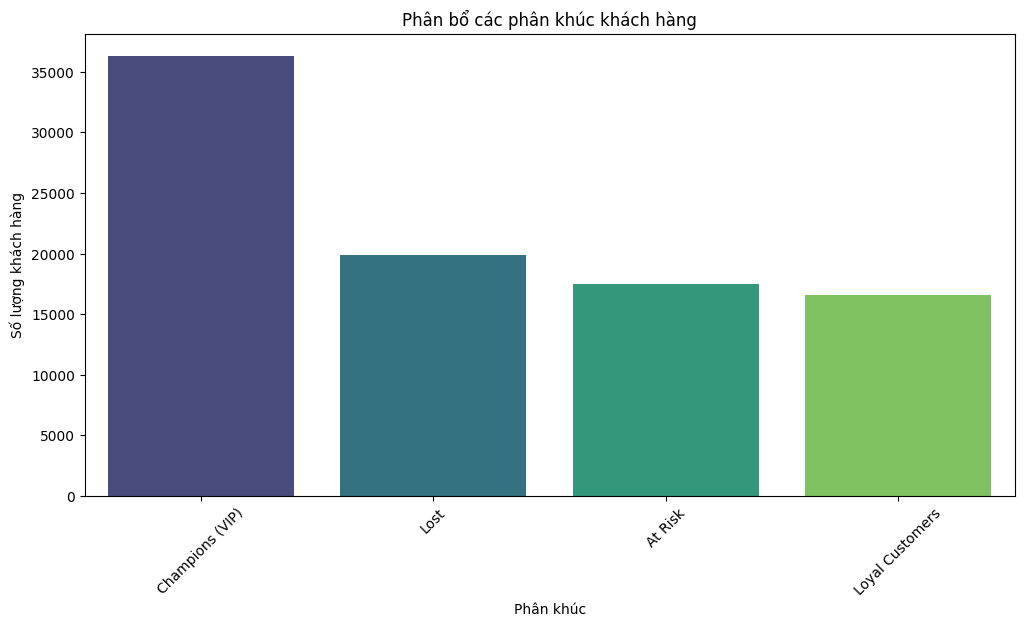

In [17]:
# 15. Đếm số lượng khách hàng trong mỗi phân khúc
segment_counts = rfm['Segment_Name'].value_counts().reset_index()

# Đặt lại tên cột để chắc chắn không bị nhầm lẫn
segment_counts.columns = ['Segment_Name', 'Count'] 


plt.figure(figsize=(12, 6))

# 17. Vẽ biểu đồ với tên cột mới đã định nghĩa
sns.barplot(data=segment_counts, x='Segment_Name', y='Count', palette='viridis')

plt.title('Phân bổ các phân khúc khách hàng')
plt.xlabel('Phân khúc')
plt.ylabel('Số lượng khách hàng')
plt.xticks(rotation=45) # Xoay chữ cho dễ đọc nếu tên phân khúc dài
plt.show()

In [18]:
total_customers = segment_counts['Count'].sum()
segment_counts['Percentage'] = (segment_counts['Count'] / total_customers * 100).round(2)
print(segment_counts)

      Segment_Name  Count  Percentage
0  Champions (VIP)  36307       40.23
1             Lost  19873       22.02
2          At Risk  17495       19.39
3  Loyal Customers  16571       18.36


# 2. Phân tích Sản phẩm & Doanh thu (Product & Sales Performance)
Sử dụng orders, order_items, products, promotions:

Phân tích Pareto (Quy tắc 80/20): Xác định 20% sản phẩm mang lại 80% doanh thu.

Market Basket Analysis (Phân tích giỏ hàng): Tìm các cặp sản phẩm thường được mua cùng nhau (Ví dụ: khách mua điện thoại thường mua thêm ốp lưng).

Action: Đề xuất chiến thuật Cross-selling hoặc đóng gói Combo.

Hiệu quả khuyến mãi: So sánh doanh thu và lợi nhuận giữa các sản phẩm có sử dụng promotions và không sử dụng.

In [34]:
import pandas as pd 
df_orders = pd.read_csv('./data/orders.csv')
df_items = pd.read_csv('./data/order_items.csv')
df_products = pd.read_csv('./data/products.csv')
df_promo = pd.read_csv('./data/promotions.csv')
df_inventory = pd.read_csv('./data/inventory.csv')



/var/folders/tn/l785m_3s5bg6mvddm1v1pb_c0000gn/T/ipykernel_14080/111671882.py:3: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_items = pd.read_csv('./data/order_items.csv')


In [30]:
# Tính doanh thu mỗi sản phẩm
prod_sales = df_items.groupby('product_id')['unit_price'].sum().reset_index()
prod_sales = prod_sales.sort_values(by='unit_price', ascending=False)

# Tính % tích lũy
prod_sales['cum_percentage'] = 100 * prod_sales['unit_price'].cumsum() / prod_sales['unit_price'].sum()

# Xác định nhóm 80% doanh thu
top_20_products = prod_sales[prod_sales['cum_percentage'] <= 80]

## Biểu đồ Pareto (Quy tắc 80/20)
Đây là biểu đồ kết hợp giữa cột (doanh thu từng sản phẩm) và đường (tổng tích lũy %).

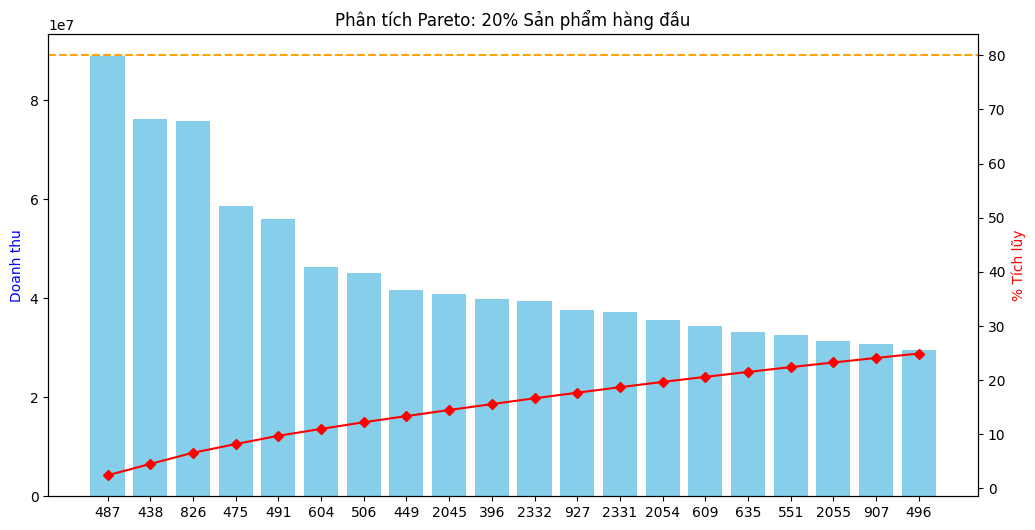

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử đã có dataframe prod_sales từ bước trước
fig, ax1 = plt.subplots(figsize=(12, 6))

# Vẽ cột doanh thu
ax1.bar(prod_sales['product_id'].astype(str)[:20], prod_sales['unit_price'][:20], color='skyblue')
ax1.set_ylabel('Doanh thu', color='b')

# Vẽ đường tích lũy %
ax2 = ax1.twinx()
ax2.plot(prod_sales['product_id'].astype(str)[:20], prod_sales['cum_percentage'][:20], color='red', marker='D', ms=5)
ax2.axhline(80, color='orange', linestyle='--') # Đường kẻ 80%
ax2.set_ylabel('% Tích lũy', color='r')

plt.title('Phân tích Pareto: 20% Sản phẩm hàng đầu')
plt.show()

##  Ma trận Hiệu quả Khuyến mãi
Để so sánh nhóm có Promotion và không có Promotion, biểu đồ Boxplot hoặc Violin plot là lựa chọn tuyệt vời để thể hiện sự khác biệt về giá trị đơn hàng (AOV).

/var/folders/tn/l785m_3s5bg6mvddm1v1pb_c0000gn/T/ipykernel_14080/3083661709.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='has_promo', y='unit_price', data=df_items, palette='Set2')


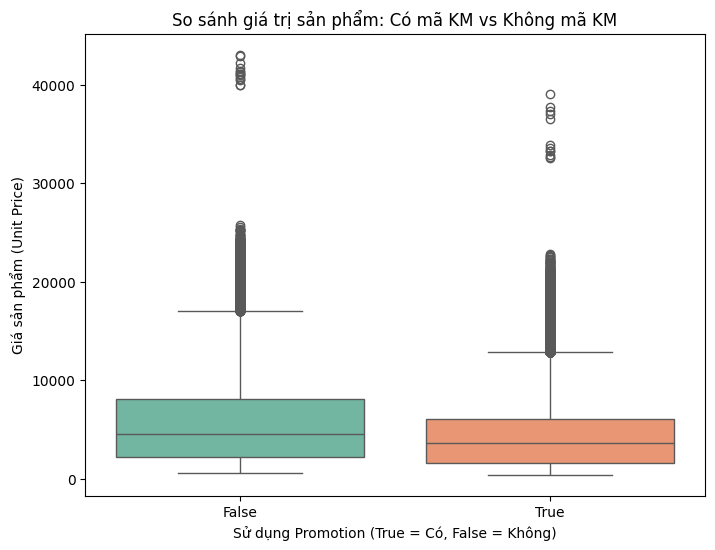

In [ ]:

# Nếu promo_id có giá trị (không phải NaN/Null) thì là True
df_items['has_promo'] = df_items['promo_id'].notna()

# 2. Bây giờ mới chạy lệnh vẽ biểu đồ
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x='has_promo', y='unit_price', data=df_items, palette='Set2')

plt.title('So sánh giá trị sản phẩm: Có mã KM vs Không mã KM')
plt.xlabel('Sử dụng Promotion (True = Có, False = Không)')
plt.ylabel('Giá sản phẩm (Unit Price)')
plt.show()

## Phân tích Tồn kho (Inventory vs Sales)
Để đạt cấp độ Prescriptive, bạn nên vẽ biểu đồ kết hợp giữa units_sold và stock_on_hand từ bảng inventory.
* Sản phẩm "Nóng": Doanh số cao, tồn kho thấp (Cần nhập hàng gấp).
* Sản phẩm "Lạnh": Doanh số thấp, tồn kho cao (Cần chạy Promotion để xả kho).

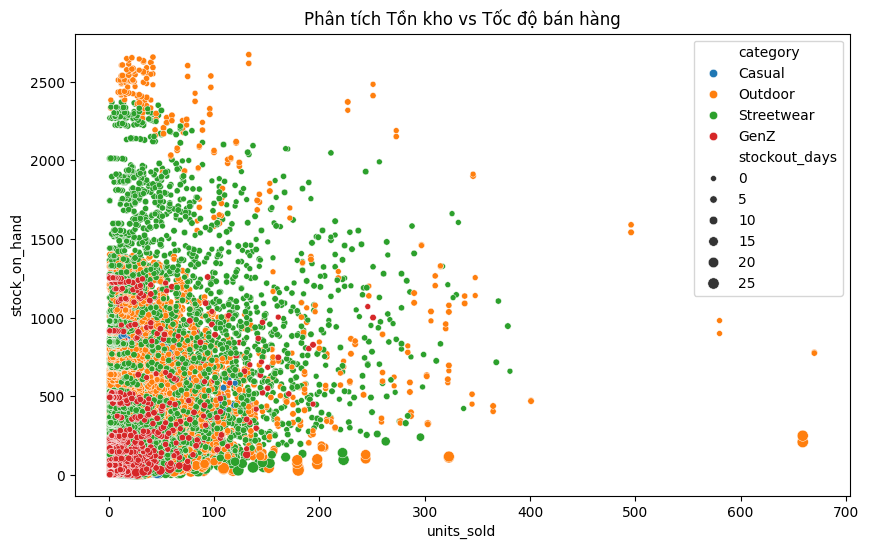

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_inventory, x='units_sold', y='stock_on_hand', hue='category', size='stockout_days')
plt.title('Phân tích Tồn kho vs Tốc độ bán hàng')
plt.show()

# 3. Phân tích Vận hành & Chuỗi cung ứng (Operations & Logistics)
Sử dụng shipments, geography, returns:

Thời gian giao hàng (Delivery Performance): Tính khoảng cách từ lúc đặt hàng đến lúc nhận hàng.

Địa lý: Khu vực nào có thời gian giao hàng chậm nhất? Có liên quan đến mã zip không?

Phân tích tỷ lệ trả hàng (Returns Analysis): Sản phẩm nào hoặc kênh marketing nào (order_source) có tỷ lệ trả hàng cao bất thường? Tìm hiểu nguyên nhân do chất lượng sản phẩm hay do kỳ vọng sai lệch từ quảng cáo.

In [46]:
df_shipments = pd.read_csv('./data/shipments.csv')
df_geo = pd.read_csv('./data/geography.csv') 
df_returns =pd.read_csv('./data/returns.csv') 

## Phân tích Thời gian giao hàng (Delivery Performance)
Mục tiêu là đo lường Lead Time (Thời gian từ khi đặt hàng đến khi nhận hàng).

In [38]:
# Chuyển đổi định dạng ngày tháng
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_shipments['delivery_date'] = pd.to_datetime(df_shipments['delivery_date'])

# Merge hai bảng
df_logistics = pd.merge(df_orders, df_shipments, on='order_id')

# Tính thời gian giao hàng (đơn vị: ngày)
df_logistics['delivery_time'] = (df_logistics['delivery_date'] - df_logistics['order_date']).dt.days

# Thống kê mô tả
print(df_logistics['delivery_time'].describe())

count    566067.000000
mean          5.997594
std           2.040460
min           2.000000
25%           4.000000
50%           6.000000
75%           7.000000
max          10.000000
Name: delivery_time, dtype: float64


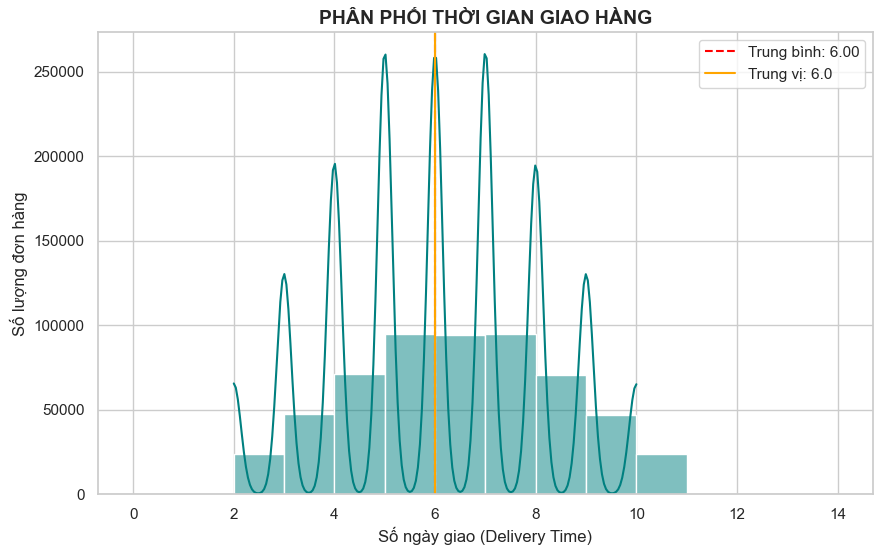

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# bins=range(0, 20) giúp chia cột theo từng ngày một cách rõ ràng
sns.histplot(df_logistics['delivery_time'], bins=range(0, 15), kde=True, color='teal')

# Vẽ đường trung bình (Mean) và Trung vị (Median)
plt.axvline(df_logistics['delivery_time'].mean(), color='red', linestyle='--', label=f"Trung bình: {df_logistics['delivery_time'].mean():.2f}")
plt.axvline(df_logistics['delivery_time'].median(), color='orange', linestyle='-', label=f"Trung vị: {df_logistics['delivery_time'].median()}")

plt.title('PHÂN PHỐI THỜI GIAN GIAO HÀNG', fontsize=14, fontweight='bold')
plt.xlabel('Số ngày giao (Delivery Time)')
plt.ylabel('Số lượng đơn hàng')
plt.legend()
plt.show()

## Phân tích Địa lý (Geography Analysis)
Tìm "điểm đen" về logistics.

In [54]:
# Bước 1: Chuyển định dạng ngày tháng cho chuẩn
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_shipments['delivery_date'] = pd.to_datetime(df_shipments['delivery_date'])

# Bước 2: Kết nối orders và shipments để tính thời gian giao hàng
# Mình đặt tên bảng mới là df_analysis
df_analysis = pd.merge(df_orders, df_shipments, on='order_id')
df_analysis['delivery_time'] = (df_analysis['delivery_date'] - df_analysis['order_date']).dt.days

# Bước 3: Kết nối với bảng địa lý (df_geo) qua cột 'zip'
# Bây giờ df_final sẽ có cả 'region' và 'delivery_time'
df_final = pd.merge(df_analysis, df_geo, on='zip')

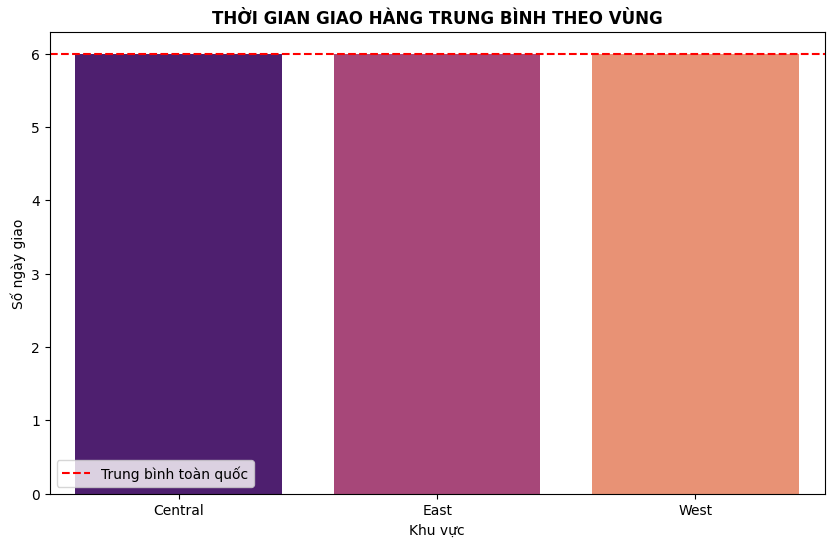

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tính trung bình theo vùng
geo_data = df_final.groupby('region')['delivery_time'].mean().sort_values().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=geo_data, x='region', y='delivery_time', hue='region', palette='magma', legend=False)

# Thêm đường trung bình để đối chiếu
plt.axhline(df_final['delivery_time'].mean(), color='red', linestyle='--', label='Trung bình toàn quốc')

plt.title('THỜI GIAN GIAO HÀNG TRUNG BÌNH THEO VÙNG', fontweight='bold')
plt.ylabel('Số ngày giao')
plt.xlabel('Khu vực')
plt.legend()
plt.show()

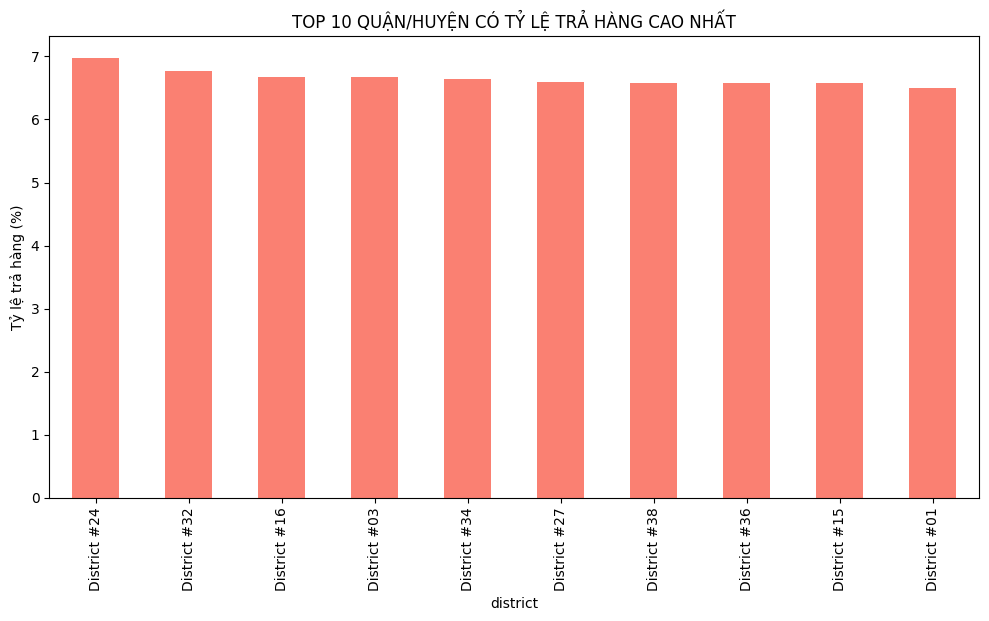

In [57]:
# Đánh dấu đơn hàng nào bị trả lại
df_final['is_returned'] = df_final['order_id'].isin(df_returns['order_id'])

# Tính tỷ lệ trả hàng theo District (lấy top 10 huyện tệ nhất)
district_returns = df_final.groupby('district')['is_returned'].mean().sort_values(ascending=False).head(10) * 100

plt.figure(figsize=(12, 6))
district_returns.plot(kind='bar', color='salmon')
plt.title('TOP 10 QUẬN/HUYỆN CÓ TỶ LỆ TRẢ HÀNG CAO NHẤT')
plt.ylabel('Tỷ lệ trả hàng (%)')
plt.show()

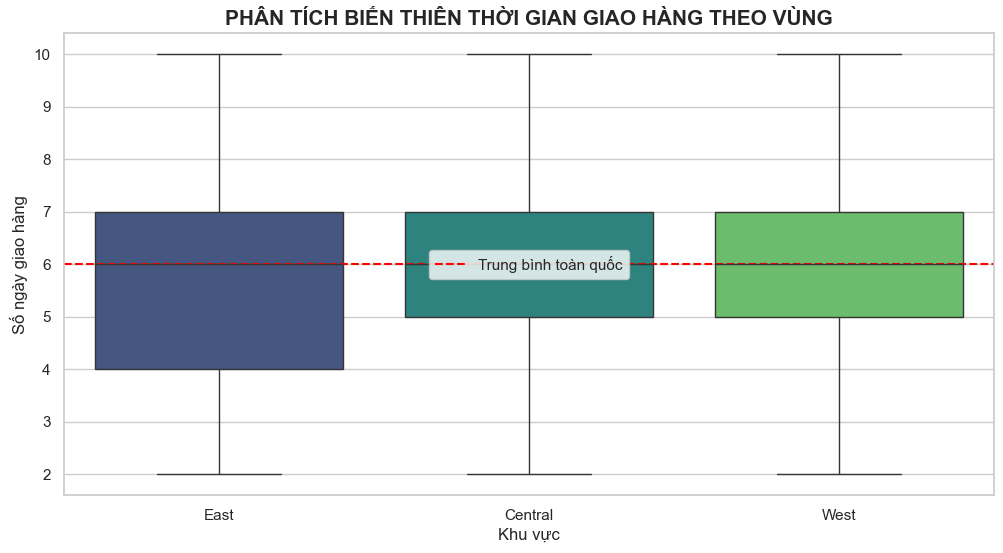

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# Thiết lập style cho chuyên nghiệp
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 1. Vẽ biểu đồ Boxplot để thấy sự biến thiên (thay vì chỉ xem trung bình)
# Cấp độ: Diagnostic - Giải thích sự bất thường
sns.boxplot(data=df_final, x='region', y='delivery_time', palette='viridis', hue='region', legend=False)

# 2. Vẽ đường trung bình toàn quốc để so sánh
plt.axhline(df_final['delivery_time'].mean(), color='red', linestyle='--', label='Trung bình toàn quốc')

plt.title('PHÂN TÍCH BIẾN THIÊN THỜI GIAN GIAO HÀNG THEO VÙNG', fontsize=15, fontweight='bold')
plt.xlabel('Khu vực', fontsize=12)
plt.ylabel('Số ngày giao hàng', fontsize=12)
plt.legend()
plt.show()

#### ? Dựa trên bảng df_final, bạn hãy đề xuất: "Dựa trên phân tích địa lý, chúng tôi kiến nghị phân bổ lại tồn kho (Inventory) dựa trên nhu cầu của từng region. Những vùng có delivery_time cao cần được ưu tiên sử dụng dịch vụ vận chuyển hỏa tốc hoặc mở thêm trạm trung chuyển để giảm tỷ lệ khách hàng rời bỏ (Churn rate) do chờ đợi quá lâu."

# 4. Phân tích Trải nghiệm người dùng & Kênh (Digital & Marketing)
Sử dụng web_traffic, reviews, device_type, order_source:

Tỷ lệ chuyển đổi (Conversion Rate): Kết hợp web_traffic và orders để xem thiết bị nào (device_type) hoặc nguồn nào (order_source) mang lại hiệu quả chuyển đổi cao nhất.

Sentiment Analysis (Phân tích cảm xúc): Từ bảng reviews, phân tích mối tương quan giữa điểm số đánh giá và thời gian giao hàng hoặc loại sản phẩm.